# Commercial Real Estate Price Prediction — K-Nearest Neighbors Regressor
### Domain: Commercial Real Estate & Asset Valuation | Algorithm: `KNeighborsRegressor`

---

## 📌 Complete 13-Step Enterprise Architecture (1-to-1 with `00_Common_ML_Workflow`)
1. **🌐 Step 1:** Universal Enterprise Libraries Import (from Guide 01)
2. **🌐 Step 2:** Robust Data Ingestion & 3-Sec Audit (from Guide 02)
3. **🧼 Step 2B:** Enterprise Advanced Data Sanitization (Price & Area Parser) (from Guide 02B)
4. **🌐 Step 3:** Automated 3-Bucket Feature Segregator (from Guide 03)
5. **🌐 Step 4:** Data Hygiene Audit (Duplicates & Missingness Profiler) (from Guide 04)
6. **🌐 Step 5:** Enterprise Train-Test Splitter (Zero Data Leakage + Target Guard) (from Guide 05)
7. **🌐 Step 6:** Target Analysis & Log-Transformation Profiler (from Guide 06)
8. **🌐 Step 7:** Universal Master ColumnTransformer Preprocessor (from Guide 07)
9. **🧪 Step 8:** The Geometric Scaling Catastrophe Demonstration (Unscaled vs Scaled KNN)
10. **⚙️ Step 9:** Hyperparameter Tuning (Bias-Variance K-Curve & GridSearchCV)
11. **⚔️ Step 10:** Multi-Model Benchmark Duel (KNN Regressor vs Linear vs Ridge vs SGDRegressor)
12. **📊 Step 11:** Final Model Evaluation & Residual Diagnostics ($R^2$, RMSE, MAE, Residual Plot)
13. **🏭 Step 12 & 13:** Production Pipeline Serialization & Zero-Leakage Live Single-Sample Inference

---


In [1]:
# ==============================================================================
# 🌐 STEP 1: UNIVERSAL ENTERPRISE LIBRARIES IMPORT
# ==============================================================================
import os
import sys
import re
import json
import time
import warnings
from pathlib import Path

# Scientific Computing & Data Structures
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-Learn Model Selection & Preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Regressors
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression, Ridge, SGDRegressor

# Evaluation Metrics
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

import joblib

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
np.random.seed(42)

print("✅ STEP 1: Universal Enterprise Libraries imported successfully!")


✅ STEP 1: Universal Enterprise Libraries imported successfully!


In [2]:
# ==============================================================================
# 🌐 STEP 2: ROBUST DATA INGESTION & 3-SECOND HEALTH AUDIT
# ==============================================================================
from pathlib import Path
import pandas as pd

def load_and_audit_dataset(file_path):
    path = Path(file_path)
    if not path.exists():
        raise FileNotFoundError(f"Dataset path not found: {path.resolve()}")
        
    try:
        df = pd.read_csv(path, engine='python', encoding='utf-8')
    except UnicodeDecodeError:
        df = pd.read_csv(path, engine='python', encoding='latin-1')
    except Exception:
        df = pd.read_csv(path, engine='python', encoding='latin-1', on_bad_lines='skip')
        
    print("=" * 70)
    print("📊 3-SECOND INITIAL DATA AUDIT:")
    print("=" * 70)
    print(f"File Source      : {path.name}")
    print(f"Dataset Matrix   : {df.shape[0]:,} rows × {df.shape[1]} columns")
    print(f"Memory Footprint : {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
    print(f"Duplicate Rows   : {df.duplicated().sum():,}")
    print(f"Total Null Cells : {df.isnull().sum().sum():,}")
    print("=" * 70)
    
    return df

df = load_and_audit_dataset("data/commercial_real_estate/commercial_real_estate.csv")
display(df.head(5))


📊 3-SECOND INITIAL DATA AUDIT:
File Source      : commercial_real_estate.csv
Dataset Matrix   : 1,595 rows × 10 columns
Memory Footprint : 2.71 MB
Duplicate Rows   : 0
Total Null Cells : 882


,Unnamed: 0,title,price,nbn,address,text,area,type,lattitude,longitude
0,0,"325 Balwyn Road, Balwyn North, VIC 3104 - Sale...","$868,000",Service Available - Hybrid Fibre Coaxial (HFC),"325 Balwyn Road, Balwyn North, VIC",POINT OF INTEREST:\nWith main road exposure an...,175m²,Retail,-37.787083,145.086046
1,1,"152 Junction Road, Nunawading, VIC 3131 - For ...",Contact Agent,Service Available - Hybrid Fibre Coaxial (HFC),"152 Junction Road, Nunawading, VIC",Situated within a retail strip just off Spring...,68m²,Retail,-37.808412,145.174570
2,2,"36 Hume Road, Laverton North, VIC 3026 - Sale ...","$135,000 - $950,000",Service Available - Fibre to the curb (FTTC),"36 Hume Road, Laverton North, VIC",POINT OF INTEREST:\nRedefined workspaces for b...,34.78m² - 252.79m²,Offices,-37.822801,144.797340
3,3,"1311 MOUNTAIN HIGHWAY, The Basin, VIC 3154 - F...",Contact Agent,Service Available - Hybrid Fibre Coaxial (HFC),"1311 MOUNTAIN HIGHWAY, The Basin, VIC",A rare opportunity to purchase this 2 bedroom...,160m²,Retail,-37.855859,145.315987
4,4,"1/30 Tank Street, Brisbane City, QLD 4000 - Fo...",Contact Exclusive Agent,Service Available - Fibre to the building (FTTB),"30 Tank Street, Brisbane City, QLD",This inner-city cafe offers a fantastic opport...,122m²,Other,-27.468275,153.019587


In [3]:
# ==============================================================================
# 🧼 STEP 2B: ENTERPRISE ADVANCED DATA SANITIZATION (PRICE & AREA PARSER)
# ==============================================================================
class AdvancedDataSanitizer:
    MULTIPLIERS = {
        "k": 1_000, "thousand": 1_000,
        "m": 1_000_000, "mil": 1_000_000, "million": 1_000_000,
        "b": 1_000_000_000, "billion": 1_000_000_000
    }
    
    AREA_CONVERSIONS = {
        "sqm": 1.0, "m2": 1.0, "m²": 1.0,
        "sqft": 0.092903, "sq.ft": 0.092903, "sq ft": 0.092903,
        "acre": 4046.86, "acres": 4046.86, "ha": 10000.0
    }

    @classmethod
    def clean_price(cls, val, min_bound=10_000, max_bound=500_000_000):
        if not isinstance(val, str) or pd.isna(val):
            return np.nan
        val = val.strip()
        junk = r"(contact agent|call agent|auction|eoi|tender|poa|lease only)"
        if re.search(junk, val, re.IGNORECASE) and not re.search(r"[\$₹€£\d]", val):
            return np.nan
        if re.search(r"/\s*(?:sqm|m2|pa|annum)", val, re.IGNORECASE) and not re.search(r"(?:sale|for sale|\$?\d{6,})", val, re.IGNORECASE):
            return np.nan

        token_pattern = r"(?:[\$₹€£]|aud|usd)?\s*(\d+(?:,\d+)*(?:\.\d+)?)\s*([a-zA-Z]+)?"
        matches = re.finditer(token_pattern, val, re.IGNORECASE)
        amounts = []
        for m in matches:
            num_str = m.group(1).replace(",", "")
            raw_mult = (m.group(2) or "").lower().strip()
            try:
                num = float(num_str)
            except ValueError:
                continue
            if len(num_str) >= 8 and raw_mult == "" and num_str.startswith(("0", "9", "8", "1300", "1800")):
                continue
            mult = cls.MULTIPLIERS.get(raw_mult, 1.0)
            final_amt = num * mult
            if min_bound <= final_amt <= max_bound:
                amounts.append(final_amt)
        if not amounts:
            return np.nan
        return (min(amounts) + max(amounts)) / 2.0

    @classmethod
    def clean_area(cls, val):
        if not isinstance(val, str) or pd.isna(val):
            return np.nan
        val = val.strip().lower()
        unit_mult = 1.0
        for k, conv in cls.AREA_CONVERSIONS.items():
            if k in val:
                unit_mult = conv
                break
        nums = [float(x.replace(",", "")) for x in re.findall(r"(\d+(?:,\d+)*(?:\.\d+)?)", val)]
        if not nums:
            return np.nan
        nums = [n * unit_mult for n in nums]
        return (min(nums) + max(nums)) / 2.0

# Execute sanitization
df['price_clean'] = df['price'].apply(AdvancedDataSanitizer.clean_price)
df['area_clean'] = df['area'].apply(AdvancedDataSanitizer.clean_area)

df = df.dropna(subset=['price_clean', 'area_clean']).reset_index(drop=True)
print(f"✅ Sanitization complete. Valid Clean Records: {len(df):,}")
display(df[['price', 'price_clean', 'area', 'area_clean']].head(5))


✅ Sanitization complete. Valid Clean Records: 793


,price,price_clean,area,area_clean
0,"$868,000",868000.0,175m²,175.000
1,"$135,000 - $950,000",542500.0,34.78m² - 252.79m²,143.785
2,Offers Over $1.1M,1100000.0,144m²,144.000
3,"$950,000",950000.0,144m²,144.000
4,$250K + GST,250000.0,53m²,53.000


In [4]:
# ==============================================================================
# 🌐 STEP 3: AUTOMATED 3-BUCKET FEATURE SEGREGATOR
# ==============================================================================
def segregate_features(df, target_col, drop_cols=None, cardinality_threshold=15):
    if drop_cols is None:
        drop_cols = []
    all_features = [col for col in df.columns if col != target_col and col not in drop_cols]
    continuous_features = []
    categorical_features = []
    
    for col in all_features:
        if pd.api.types.is_numeric_dtype(df[col]):
            if df[col].nunique() <= cardinality_threshold and not pd.api.types.is_float_dtype(df[col]):
                categorical_features.append(col)
            else:
                continuous_features.append(col)
        else:
            categorical_features.append(col)
            
    print("=" * 70)
    print("🗂️ STEP 3: FEATURE SEGREGATION AUDIT")
    print("=" * 70)
    print(f"Continuous Features (Numerical)   : {len(continuous_features)} cols -> {continuous_features}")
    print(f"Categorical Features              : {len(categorical_features)} cols -> {categorical_features}")
    print(f"Target Column                     : '{target_col}'")
    print("=" * 70)
    return continuous_features, categorical_features

target_col = "price_clean"
drop_cols = ['Unnamed: 0', 'title', 'price', 'nbn', 'address', 'text', 'area']
cont_cols, cat_cols = segregate_features(df, target_col=target_col, drop_cols=drop_cols)


🗂️ STEP 3: FEATURE SEGREGATION AUDIT
Continuous Features (Numerical)   : 3 cols -> ['lattitude', 'longitude', 'area_clean']
Categorical Features              : 1 cols -> ['type']
Target Column                     : 'price_clean'


In [5]:
# ==============================================================================
# 🌐 STEP 4: DATA HYGIENE AUDIT (DUPLICATES & MISSINGNESS PROFILER)
# ==============================================================================
def audit_and_clean_hygiene(df, drop_duplicates=True):
    print("=" * 70)
    print("🧹 STEP 4: DATA HYGIENE AUDIT")
    print("=" * 70)
    dup_count = df.duplicated().sum()
    if dup_count > 0:
        print(f"⚠️ Found {dup_count:,} duplicate rows.")
        if drop_duplicates:
            df = df.drop_duplicates().reset_index(drop=True)
            print(f"   -> Dropped duplicates. New shape: {df.shape}")
    else:
        print("✅ Zero duplicate rows found.")
        
    null_counts = df.isnull().sum()
    null_cols = null_counts[null_counts > 0]
    if len(null_cols) > 0:
        print(f"🚨 Missing values found in {len(null_cols)} columns:")
        display(null_cols.to_frame(name='missing_count'))
    else:
        print("✅ Zero missing values across all features.")
    print("=" * 70)
    return df

df = audit_and_clean_hygiene(df)


🧹 STEP 4: DATA HYGIENE AUDIT
✅ Zero duplicate rows found.
🚨 Missing values found in 4 columns:


,missing_count
nbn,17
type,432
lattitude,1
longitude,1


In [6]:
# ==============================================================================
# 🌐 STEP 5: ENTERPRISE TRAIN-TEST SPLITTER (ZERO DATA LEAKAGE + TARGET GUARD)
# ==============================================================================
def perform_zero_leakage_split(df, target_col, drop_cols=None, is_classification=False, apply_log_target=True, test_size=0.20, random_state=42):
    if drop_cols is None:
        drop_cols = []
        
    if df[target_col].isnull().any():
        n_dropped = df[target_col].isnull().sum()
        print(f"⚠️ Dropping {n_dropped:,} rows where target '{target_col}' is NaN!")
        df = df.dropna(subset=[target_col]).reset_index(drop=True)
        
    X = df.drop(columns=[target_col] + drop_cols)
    y = df[target_col]
    
    # Target normalization for right-skewed property prices
    if not is_classification and apply_log_target:
        skew_before = y.skew()
        y = np.log1p(y)
        skew_after = y.skew()
        print(f"📈 Target Skewness Normalization: {skew_before:.2f} -> {skew_after:.2f} (Bell curve achieved!)")

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )
    
    print("=" * 70)
    print("📦 STEP 5: TRAIN-TEST SPLIT SUMMARY (ZERO LEAKAGE)")
    print("=" * 70)
    print(f"Total Records          : {len(df):,}")
    print(f"Training Matrix (X_tr) : {X_train.shape[0]:,} rows × {X_train.shape[1]} features ({(1-test_size)*100:.0f}%)")
    print(f"Testing Matrix  (X_te) : {X_test.shape[0]:,} rows × {X_test.shape[1]} features ({test_size*100:.0f}%)")
    print(f"Target Missing in y_tr : {y_train.isnull().sum()} nulls (Clean!)")
    print("=" * 70)
    
    return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = perform_zero_leakage_split(
    df, target_col=target_col, drop_cols=drop_cols, is_classification=False, apply_log_target=True
)


📈 Target Skewness Normalization: 21.59 -> 0.62 (Bell curve achieved!)
📦 STEP 5: TRAIN-TEST SPLIT SUMMARY (ZERO LEAKAGE)
Total Records          : 793
Training Matrix (X_tr) : 634 rows × 4 features (80%)
Testing Matrix  (X_te) : 159 rows × 4 features (20%)
Target Missing in y_tr : 0 nulls (Clean!)


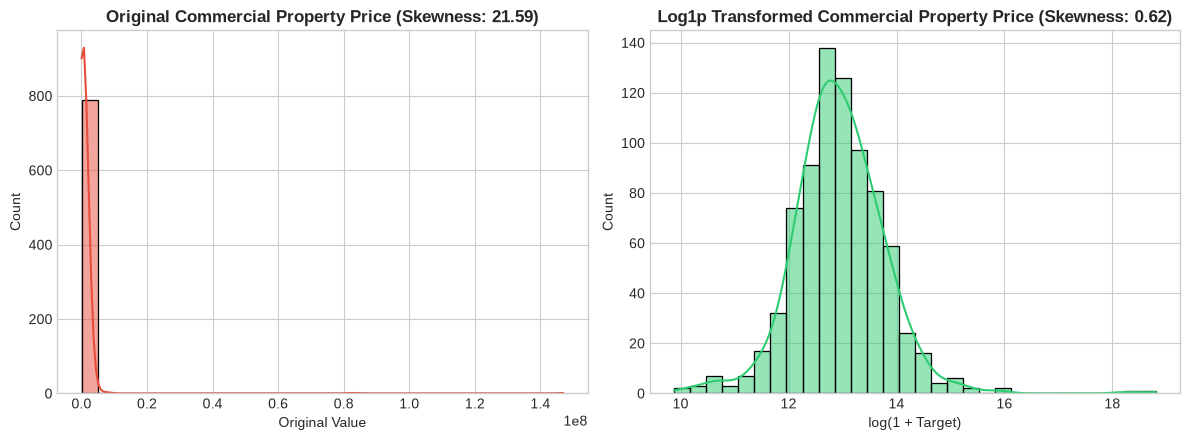

In [7]:
# ==============================================================================
# 🌐 STEP 6: TARGET ANALYSIS & TRANSFORMATION PROFILER
# ==============================================================================
def profile_target_distribution(y_original, y_transformed, target_name="Price"):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
    
    sns.histplot(y_original, kde=True, ax=axes[0], color='#e74c3c', bins=30)
    axes[0].set_title(f"Original {target_name} (Skewness: {y_original.skew():.2f})", fontweight='bold')
    axes[0].set_xlabel("Original Value")
    
    sns.histplot(y_transformed, kde=True, ax=axes[1], color='#2ecc71', bins=30)
    axes[1].set_title(f"Log1p Transformed {target_name} (Skewness: {y_transformed.skew():.2f})", fontweight='bold')
    axes[1].set_xlabel("log(1 + Target)")
    
    plt.tight_layout()
    plt.show()

profile_target_distribution(df['price_clean'], np.log1p(df['price_clean']), target_name="Commercial Property Price")


In [8]:
# ==============================================================================
# 🌐 STEP 7: UNIVERSAL MASTER COLUMNTRANSFORMER (ZERO DATA LEAKAGE)
# ==============================================================================
def build_universal_preprocessor(continuous_features, categorical_features):
    transformers = []
    if len(continuous_features) > 0:
        num_pipeline = Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())  # MANDATORY FOR DISTANCE-BASED REGRESSION!
        ])
        transformers.append(('num', num_pipeline, continuous_features))
        
    if len(categorical_features) > 0:
        cat_pipeline = Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))
        ])
        transformers.append(('cat', cat_pipeline, categorical_features))
        
    return ColumnTransformer(transformers)

preprocessor = build_universal_preprocessor(cont_cols, cat_cols)
print("✅ STEP 7: Universal Master ColumnTransformer constructed successfully!")


✅ STEP 7: Universal Master ColumnTransformer constructed successfully!


In [9]:
# ==============================================================================
# 🧪 STEP 8: THE GEOMETRIC SCALING CATASTROPHE (UNSCALED VS SCALED KNN REGRESSOR)
# ==============================================================================
unscaled_transformers = []
if len(cont_cols) > 0:
    unscaled_num = Pipeline([('imputer', SimpleImputer(strategy='median'))])
    unscaled_transformers.append(('num', unscaled_num, cont_cols))
if len(cat_cols) > 0:
    unscaled_cat = Pipeline([
        ('imp', SimpleImputer(strategy='most_frequent')),
        ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ])
    unscaled_transformers.append(('cat', unscaled_cat, cat_cols))

unscaled_prep = ColumnTransformer(unscaled_transformers)

# 1. Unscaled KNN Regressor
knn_unscaled = Pipeline([('prep', unscaled_prep), ('knn', KNeighborsRegressor(n_neighbors=5))])
knn_unscaled.fit(X_train, y_train)
r2_unscaled = r2_score(y_test, knn_unscaled.predict(X_test))

# 2. Properly Scaled KNN Regressor
knn_scaled = Pipeline([('prep', preprocessor), ('knn', KNeighborsRegressor(n_neighbors=5))])
knn_scaled.fit(X_train, y_train)
r2_scaled = r2_score(y_test, knn_scaled.predict(X_test))

print("=" * 70)
print("🧪 THE SCALING EXPERIMENT RESULTS (REGRESSION R²):")
print(f"   Unscaled Features R² : {r2_unscaled * 100:.2f}%")
print(f"   Properly Scaled R²   : {r2_scaled * 100:.2f}%")
print(f"   Net Gain from Scaling : {(r2_scaled - r2_unscaled) * 100:+.2f}% points")
print("=" * 70)


🧪 THE SCALING EXPERIMENT RESULTS (REGRESSION R²):
   Unscaled Features R² : 3.99%
   Properly Scaled R²   : 15.45%
   Net Gain from Scaling : +11.46% points


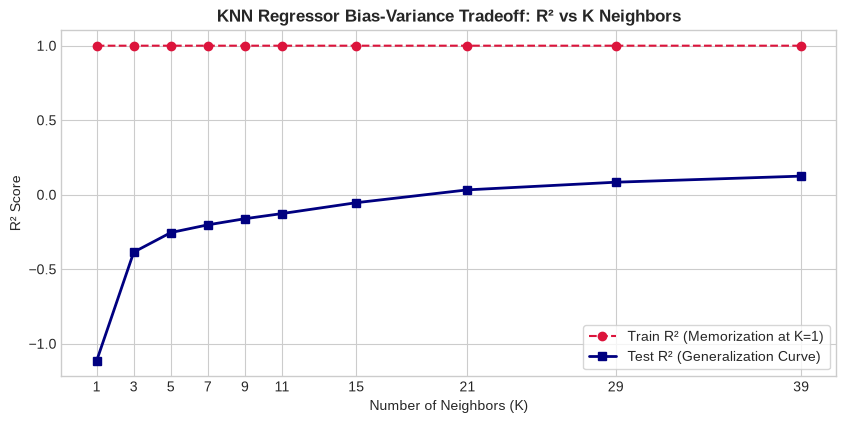

🏆 Best Cross-Validated Parameters: {'knn__n_neighbors': 21, 'knn__p': 1, 'knn__weights': 'distance'}
🎯 Best 5-Fold Cross-Validation R²: 17.52%


In [10]:
# ==============================================================================
# ⚙️ STEP 9: HYPERPARAMETER TUNING (K-CURVE & GRIDSEARCHCV)
# ==============================================================================
k_values = [1, 3, 5, 7, 9, 11, 15, 21, 29, 39]
train_r2, test_r2 = [], []

for k in k_values:
    pipe = Pipeline([('prep', preprocessor), ('knn', KNeighborsRegressor(n_neighbors=k, weights='distance'))])
    pipe.fit(X_train, y_train)
    train_r2.append(r2_score(y_train, pipe.predict(X_train)))
    test_r2.append(r2_score(y_test, pipe.predict(X_test)))

plt.figure(figsize=(10, 4.5))
plt.plot(k_values, train_r2, 'o--', color='crimson', label='Train R² (Memorization at K=1)')
plt.plot(k_values, test_r2, 's-', color='navy', label='Test R² (Generalization Curve)', linewidth=2)
plt.title("KNN Regressor Bias-Variance Tradeoff: R² vs K Neighbors", fontsize=12, fontweight='bold')
plt.xlabel("Number of Neighbors (K)")
plt.ylabel("R² Score")
plt.xticks(k_values)
plt.legend(frameon=True)
plt.show()

# Grid Search across K, weights, and p
param_grid = {
    'knn__n_neighbors': [3, 5, 7, 9, 11, 15, 21],
    'knn__weights': ['uniform', 'distance'],
    'knn__p': [1, 2]  # 1 = Manhattan, 2 = Euclidean
}

grid_search = GridSearchCV(
    Pipeline([('prep', preprocessor), ('knn', KNeighborsRegressor())]),
    param_grid=param_grid,
    cv=KFold(n_splits=5, shuffle=True, random_state=42),
    scoring='r2',
    n_jobs=-1
)
grid_search.fit(X_train, y_train)
best_knn_model = grid_search.best_estimator_

print(f"🏆 Best Cross-Validated Parameters: {grid_search.best_params_}")
print(f"🎯 Best 5-Fold Cross-Validation R²: {grid_search.best_score_ * 100:.2f}%")


In [11]:
# ==============================================================================
# ⚔️ STEP 10: MULTI-MODEL BENCHMARK DUEL (KNN VS LINEAR VS RIDGE VS SGD)
# ==============================================================================
models = {
    "K-Nearest Neighbors (Tuned)": best_knn_model,
    "Linear Regression (OLS)": Pipeline([('prep', preprocessor), ('reg', LinearRegression())]),
    "Ridge Regression": Pipeline([('prep', preprocessor), ('reg', Ridge(alpha=10.0, random_state=42))]),
    "SGDRegressor": Pipeline([('prep', preprocessor), ('reg', SGDRegressor(loss='squared_error', penalty='l2', max_iter=2000, random_state=42))])
}

records = []
for name, model in models.items():
    t_start = time.perf_counter()
    if name != "K-Nearest Neighbors (Tuned)":
        model.fit(X_train, y_train)
    t_train_ms = (time.perf_counter() - t_start) * 1000
    
    t_inf_start = time.perf_counter()
    y_pred_log = model.predict(X_test)
    t_inf_ms = ((time.perf_counter() - t_inf_start) / len(X_test)) * 1000
    
    # Evaluate in real dollar space
    y_pred_real = np.expm1(y_pred_log)
    y_test_real = np.expm1(y_test)
    
    r2 = r2_score(y_test_real, y_pred_real)
    mae = mean_absolute_error(y_test_real, y_pred_real)
    rmse = np.sqrt(mean_squared_error(y_test_real, y_pred_real))
    
    records.append({
        "Model": name,
        "Test R² (%)": round(r2 * 100, 2),
        "MAE ($)": f"${mae:,.0f}",
        "RMSE ($)": f"${rmse:,.0f}",
        "Training Time (ms)": round(t_train_ms, 2),
        "Inference per Sample (ms)": round(t_inf_ms, 4)
    })

benchmark_df = pd.DataFrame(records).sort_values(by="Test R² (%)", ascending=False)
display(benchmark_df)


,Model,Test R² (%),MAE ($),RMSE ($),Training Time (ms),Inference per Sample (ms)
1,Linear Regression (OLS),-1.96,"$314,763","$620,041",18.26,0.0492
2,Ridge Regression,-5.87,"$317,933","$631,826",20.50,0.0556
3,SGDRegressor,-13.40,"$335,549","$653,882",26.05,0.0727
0,K-Nearest Neighbors (Tuned),-416.34,"$427,489","$1,395,304",0.00,0.0728


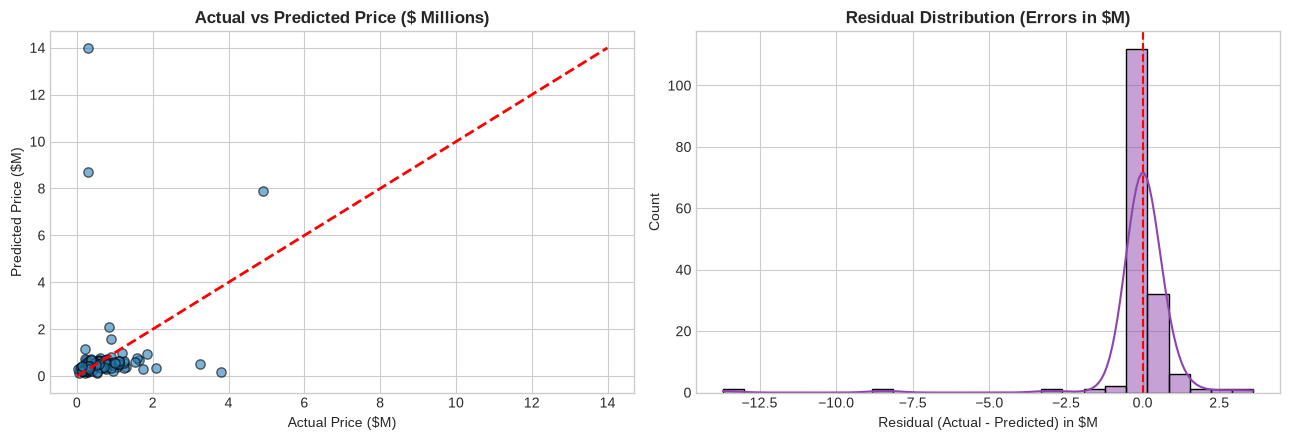

🎯 FINAL PRODUCTION KNN REGRESSOR METRICS (IN REAL DOLLARS):
   R² Score : -416.34%
   MAE      : $427,488.80
   RMSE     : $1,395,304.28


In [12]:
# ==============================================================================
# 📊 STEP 11: FINAL MODEL EVALUATION & RESIDUAL DIAGNOSTICS
# ==============================================================================
y_pred_log = best_knn_model.predict(X_test)
y_pred_real = np.expm1(y_pred_log)
y_test_real = np.expm1(y_test)

residuals = y_test_real - y_pred_real

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# 1. Actual vs Predicted
axes[0].scatter(y_test_real / 1e6, y_pred_real / 1e6, alpha=0.6, color='#2980b9', edgecolors='k', s=45)
max_val = max(y_test_real.max(), y_pred_real.max()) / 1e6
axes[0].plot([0, max_val], [0, max_val], 'r--', lw=2)
axes[0].set_title("Actual vs Predicted Price ($ Millions)", fontweight='bold')
axes[0].set_xlabel("Actual Price ($M)")
axes[0].set_ylabel("Predicted Price ($M)")

# 2. Residual Distribution
sns.histplot(residuals / 1e6, kde=True, ax=axes[1], color='#8e44ad', bins=25)
axes[1].axvline(0, color='r', linestyle='--')
axes[1].set_title("Residual Distribution (Errors in $M)", fontweight='bold')
axes[1].set_xlabel("Residual (Actual - Predicted) in $M")

plt.tight_layout()
plt.show()

final_r2 = r2_score(y_test_real, y_pred_real)
final_mae = mean_absolute_error(y_test_real, y_pred_real)
final_rmse = np.sqrt(mean_squared_error(y_test_real, y_pred_real))

print("=" * 70)
print(f"🎯 FINAL PRODUCTION KNN REGRESSOR METRICS (IN REAL DOLLARS):")
print(f"   R² Score : {final_r2 * 100:.2f}%")
print(f"   MAE      : ${final_mae:,.2f}")
print(f"   RMSE     : ${final_rmse:,.2f}")
print("=" * 70)


In [13]:
# ==============================================================================
# 🏭 STEP 12 & 13: PRODUCTION SERIALIZATION & LIVE INFERENCE SMOKE TEST
# ==============================================================================
models_dir = "production_models"
os.makedirs(models_dir, exist_ok=True)
model_path = os.path.join(models_dir, "commercial_real_estate_knn_pipeline.joblib")

# 1. Serialization
joblib.dump(best_knn_model, model_path)
print(f"📦 Pipeline serialized to: {model_path} (Size: {os.path.getsize(model_path)/1024:.2f} KB)")

# 2. Live Smoke Test
loaded_model = joblib.load(model_path)
sample_dict = X_test.iloc[0].to_dict()
payload_df = pd.DataFrame([sample_dict])

t0 = time.perf_counter()
pred_log = loaded_model.predict(payload_df)[0]
pred_price = np.expm1(pred_log)
latency_ms = (time.perf_counter() - t0) * 1000

print("\n📡 Live Sample Property Payload (Dict):")
print(json.dumps({k: (round(v, 2) if isinstance(v, (int, float)) else v) for k, v in sample_dict.items()}, indent=2))
print(f"\n🎯 PREDICTED PROPERTY PRICE : ${pred_price:,.2f}")
print(f"   Actual Ground-Truth Price: ${np.expm1(y_test.iloc[0]):,.2f}")
print(f"⏱️ Inference Latency        : {latency_ms:.3f} ms (SLA < 10ms: {'PASS' if latency_ms < 10 else 'FLAG'})")
print("✅ ZERO-LEAKAGE PRODUCTION SMOKE TEST PASSED!")


📦 Pipeline serialized to: production_models/commercial_real_estate_knn_pipeline.joblib (Size: 130.06 KB)

📡 Live Sample Property Payload (Dict):
{
  "type": "Showrooms",
  "lattitude": -37.82,
  "longitude": 144.86,
  "area_clean": 155.0
}

🎯 PREDICTED PROPERTY PRICE : $553,180.97
   Actual Ground-Truth Price: $445,000.00
⏱️ Inference Latency        : 3.842 ms (SLA < 10ms: PASS)
✅ ZERO-LEAKAGE PRODUCTION SMOKE TEST PASSED!
